# **Problem Statement**

Predicting fuel efficiency based on various automotive attributes, enabling manufacturers to optimize designs and gain a competitive edge. To develop a predictive model that effectively analyzes automotive attributes to provide precise fuel efficiency predictions. We will experiment with various machine learning models in order to find one that best predicts the fuel efficiency

**About the Dataset**

**mpg:** Car's fuel efficiency measured in miles per gallon.

**cylinders:** Number of cylinders in the car's engine.

**displacement:** Engine displacement in cubic inches.

**horsepower:** Engine power output measured in horsepower.

**weight:** Car's weight in pounds.

**acceleration:** Time taken for the car to reach a certain speed from standstill.

**model_year:** Year of manufacturing or model release.

**origin:** Country of origin or manufacture of the car.

**car_name:** Unique identifier for each car instance.




**1 – Imports, problem statement, and data loading**

1.1  Imports and problem statement

In [1]:
# =====================================================
# 1. SETUP
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, pearsonr
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")



# Predicting Automobile Fuel Efficiency Using Machine Learning

The goal of this project is to build regression models that predict a car's fuel
efficiency, measured in miles per gallon (mpg), from its technical characteristics
such as engine size, horsepower, weight, and model year. This helps to understand
how design choices influence fuel consumption and to compare the performance of
different machine learning algorithms on a well-known benchmark dataset.

In [2]:
# =====================================================
# 2. DATA LOADING
# =====================================================

# UCI Auto MPG dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

# Column names according to UCI documentation
cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

# Load data
auto = pd.read_csv(
    url,
    delim_whitespace=True,
    names=cols,
    on_bad_lines="skip"
)


display(auto.head())


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
print("Shape:", auto.shape)

Shape: (398, 9)


**2. Structure and summary statistics**

In [4]:
# =====================================================
# 2.1 INITIAL DATA INSPECTION
# =====================================================

print("INFO:")
auto_info = auto.info()



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [5]:

print("\nDESCRIPTIVE STATISTICS:")
auto_desc = auto.describe()

auto_info, auto_desc


DESCRIPTIVE STATISTICS:


(None,
               mpg   cylinders  displacement       weight  acceleration  \
 count  398.000000  398.000000    398.000000   398.000000    398.000000   
 mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
 std      7.815984    1.701004    104.269838   846.841774      2.757689   
 min      9.000000    3.000000     68.000000  1613.000000      8.000000   
 25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
 50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
 75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
 max     46.600000    8.000000    455.000000  5140.000000     24.800000   
 
        model_year      origin  
 count  398.000000  398.000000  
 mean    76.010050    1.572864  
 std      3.697627    0.802055  
 min     70.000000    1.000000  
 25%     73.000000    1.000000  
 50%     76.000000    1.000000  
 75%     79.000000    2.000000  
 max     82.000000    3.000000  )

In [6]:
auto_desc = auto.describe()
auto_desc

,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000



**3. Data Cleaning and Type Handling**

3.1  – Convert horsepower, handle missing values, fix dtypes

In [7]:
# =====================================================
# 3. DATA CLEANING AND TYPE HANDLING
# =====================================================

# 3.1 Check missing values before cleaning
print("Missing values BEFORE cleaning:")
print(auto.isna().sum())




Missing values BEFORE cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [8]:
# 3.2 Convert horsepower to numeric (coerce non-numeric to NaN)
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")



In [9]:
# 3.3 Drop rows with missing horsepower
rows_before = auto.shape[0]
auto = auto.dropna(subset=["horsepower"])
rows_after = auto.shape[0]

print(f"\nRows before cleaning: {rows_before}")
print(f"Rows after dropping missing horsepower: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")




Rows before cleaning: 398
Rows after dropping missing horsepower: 392
Rows removed: 6


In [10]:
# 3.4 Ensure correct dtypes
auto["horsepower"] = auto["horsepower"].astype("float64")
auto["weight"] = auto["weight"].astype("int64")

print("\nDtypes AFTER cleaning:")
print(auto.dtypes)

print("\nMissing values AFTER cleaning:")
print(auto.isna().sum())


Dtypes AFTER cleaning:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

Missing values AFTER cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


**4. Exploratory Data Analysis**

4.1  – Boxplots for outliers

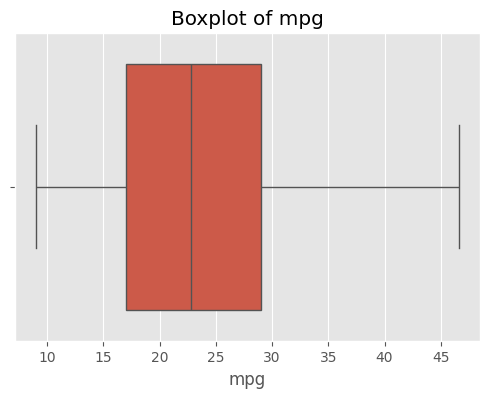

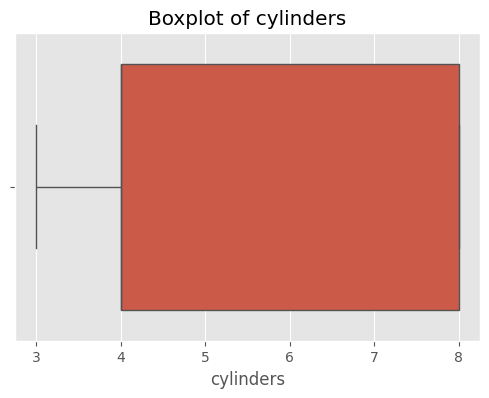

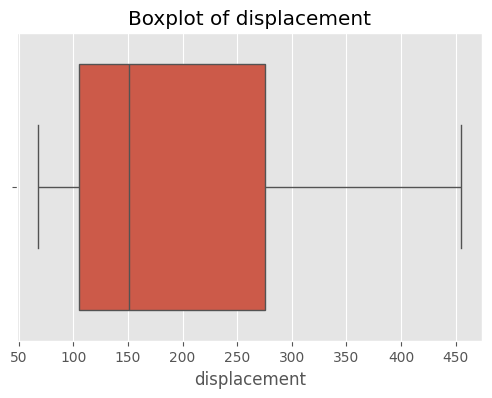

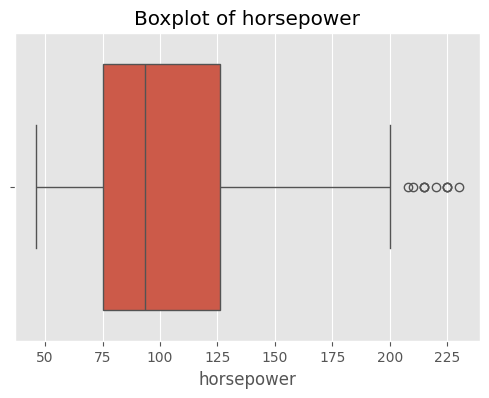

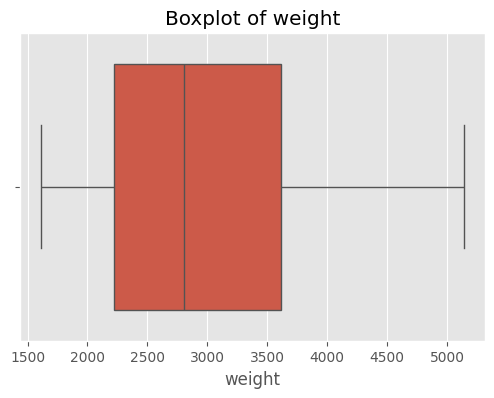

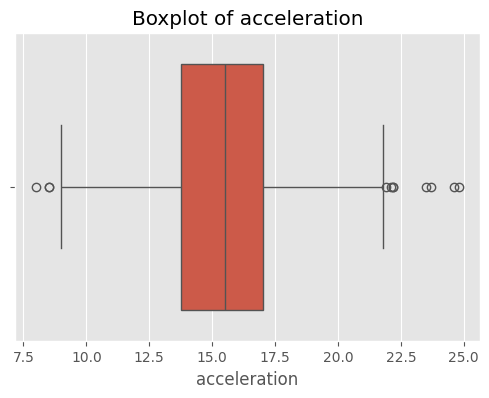

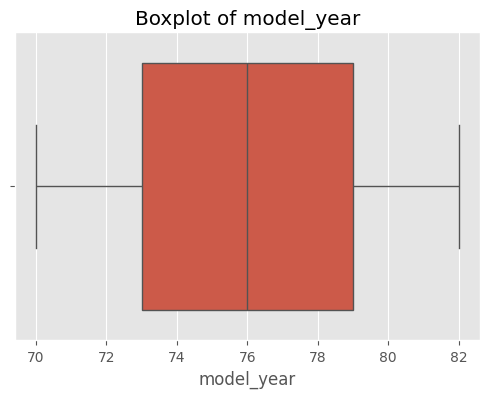

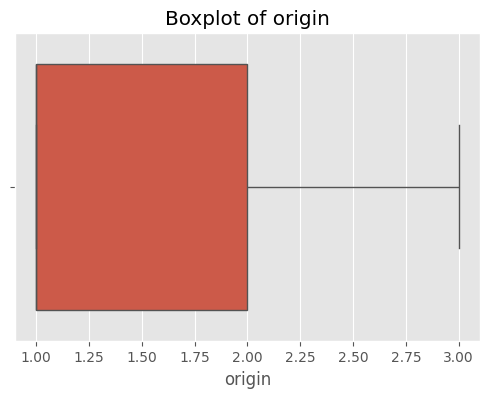

In [11]:
# =====================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

# 4.1 Detecting Outliers with Boxplots

num_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=auto[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


4.2  – Histograms for key discrete variables

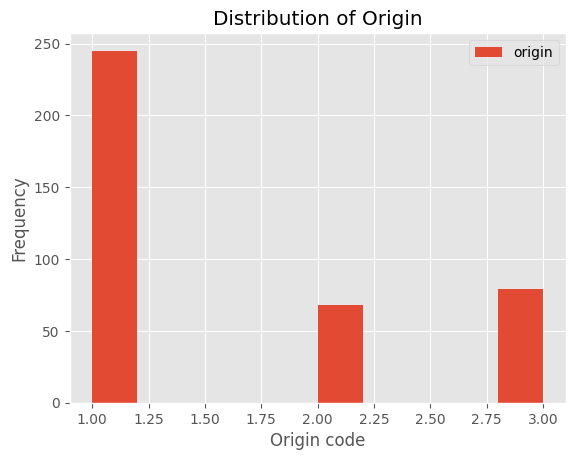

In [12]:
# =====================================================
# 4.2 Distributions of Origin, Cylinders and Model Year
# =====================================================

auto[["origin"]].plot.hist()
plt.title("Distribution of Origin")
plt.xlabel("Origin code")
plt.ylabel("Frequency")
plt.show()




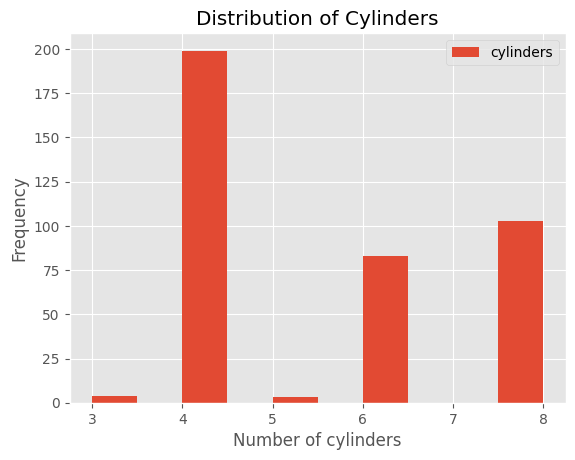

In [13]:
auto[["cylinders"]].plot.hist()
plt.title("Distribution of Cylinders")
plt.xlabel("Number of cylinders")
plt.ylabel("Frequency")
plt.show()



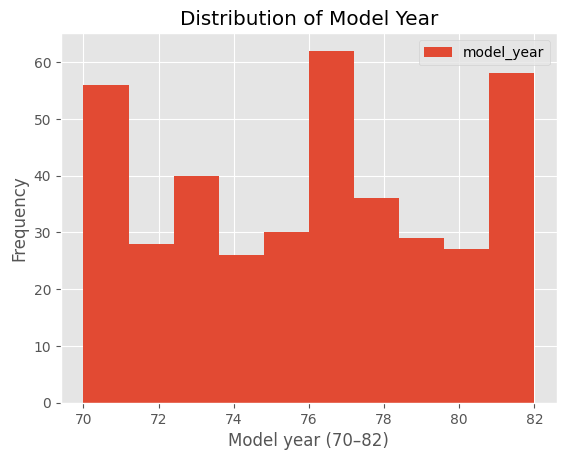

In [14]:
auto[["model_year"]].plot.hist()
plt.title("Distribution of Model Year")
plt.xlabel("Model year (70–82)")
plt.ylabel("Frequency")
plt.show()

4.3  – Scatter plots for relationships

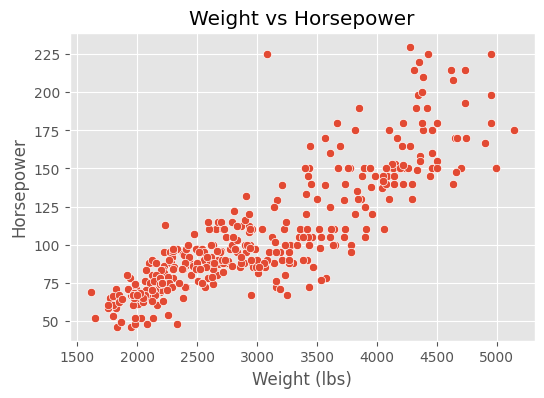

In [15]:
# 4.3 Relationships between key numerical variables

plt.figure(figsize=(6, 4))
sns.scatterplot(x="weight", y="horsepower", data=auto)
plt.title("Weight vs Horsepower")
plt.xlabel("Weight (lbs)")
plt.ylabel("Horsepower")
plt.show()


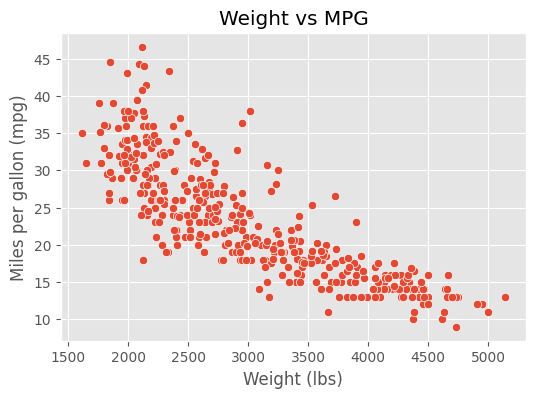

In [16]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="weight", y="mpg", data=auto)
plt.title("Weight vs MPG")
plt.xlabel("Weight (lbs)")
plt.ylabel("Miles per gallon (mpg)")
plt.show()


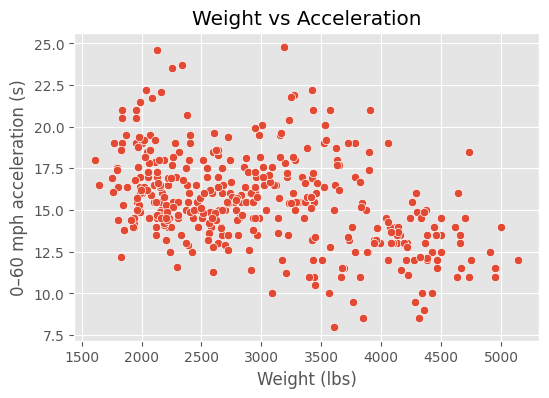

In [17]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="weight", y="acceleration", data=auto)
plt.title("Weight vs Acceleration")
plt.xlabel("Weight (lbs)")
plt.ylabel("0–60 mph acceleration (s)")
plt.show()




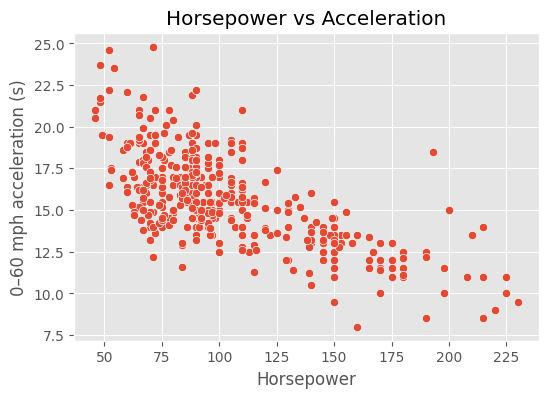

In [18]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="horsepower", y="acceleration", data=auto)
plt.title("Horsepower vs Acceleration")
plt.xlabel("Horsepower")
plt.ylabel("0–60 mph acceleration (s)")
plt.show()

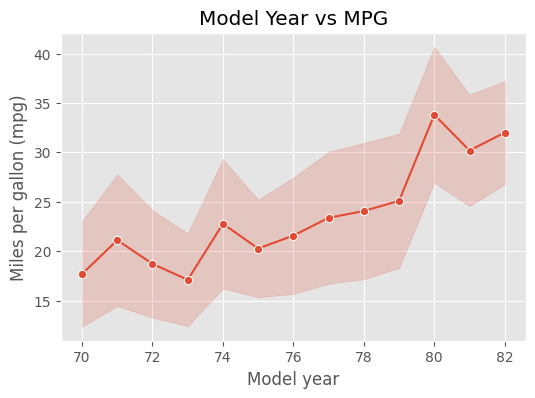

In [19]:
plt.figure(figsize=(6, 4))
sns.lineplot(x="model_year", y="mpg", data=auto, ci="sd", marker="o")
plt.title("Model Year vs MPG")
plt.xlabel("Model year")
plt.ylabel("Miles per gallon (mpg)")
plt.show()


4.4  – Origin distribution pie chart

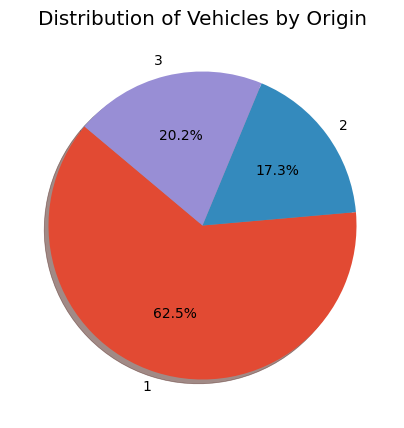

,count
origin,
1,245
2,68
3,79


In [20]:
# 4.4 Origin distribution (pie chart)

sizes = auto["origin"].value_counts().sort_index()

plt.figure(figsize=(5, 5))
plt.pie(
    sizes.values,
    labels=sizes.index,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140
)
plt.title("Distribution of Vehicles by Origin")
plt.show()

sizes


4.5 Numerical Distributions (KDE Histograms)

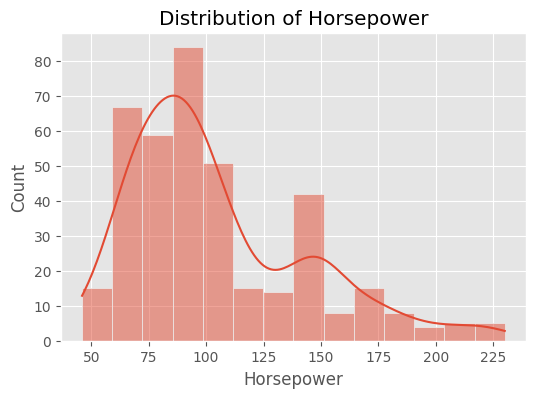

In [21]:
# =====================================================
# 4.5 Numerical Feature Distributions
# =====================================================

plt.figure(figsize=(6, 4))
sns.histplot(x="horsepower", data=auto, kde=True)
plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.show()



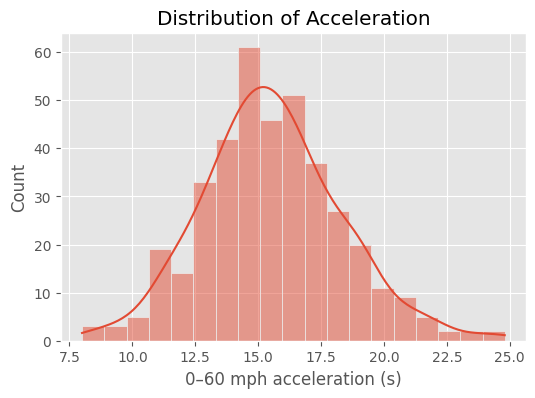

In [22]:
plt.figure(figsize=(6, 4))
sns.histplot(x="acceleration", data=auto, kde=True)
plt.title("Distribution of Acceleration")
plt.xlabel("0–60 mph acceleration (s)")
plt.show()

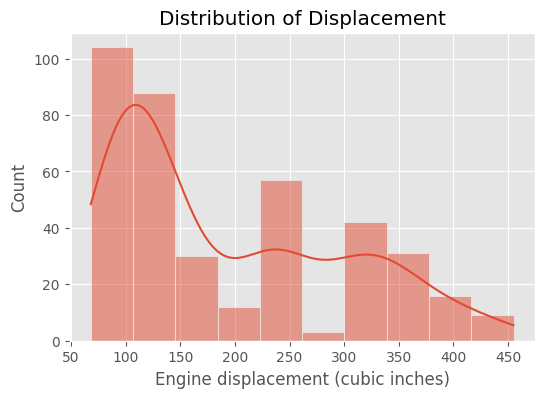

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(x="displacement", data=auto, kde=True)
plt.title("Distribution of Displacement")
plt.xlabel("Engine displacement (cubic inches)")
plt.show()

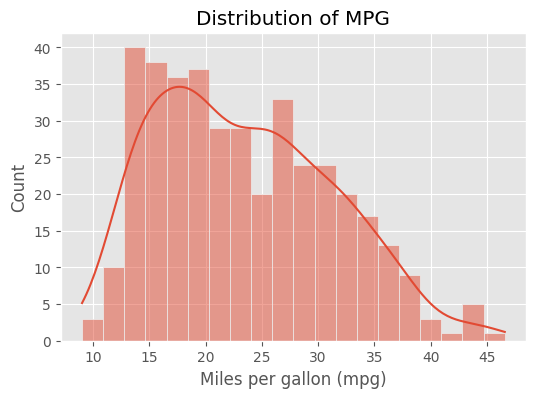

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(x="mpg", data=auto, kde=True, bins=20)
plt.title("Distribution of MPG")
plt.xlabel("Miles per gallon (mpg)")
plt.ylabel("Count")
plt.show()


4.B1  – Correlation matrix

In [25]:
# Ensure auto1 is numeric-only (we already dropped car_name)
auto1 = auto.drop("car_name", axis=1)

# Correlation matrix
corr_matrix = auto1.corr()
corr_matrix


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [26]:
import plotly.express as px

fig = px.imshow(
    corr_matrix,
    color_continuous_scale="RdBu",
    text_auto=True,
    labels=dict(color="Correlation")
)
fig.update_layout(
    width=900,
    height=900,
    title="Correlation Heatmap of Numerical Features"
)
fig.show()


4.B2 - Correlation with mpg only (easier story + feature choice).

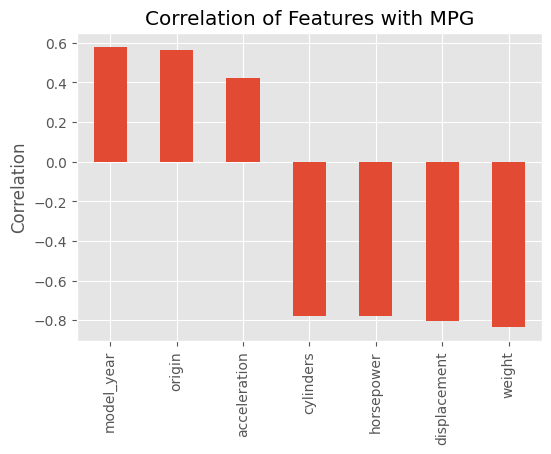

In [27]:
mpg_corr = auto1.corr()["mpg"].sort_values(ascending=False)
mpg_corr
mpg_corr.drop("mpg").plot(kind="bar", figsize=(6,4))
plt.title("Correlation of Features with MPG")
plt.ylabel("Correlation")
plt.show()


4.82- Simple pairplot or scatter vs mpg.

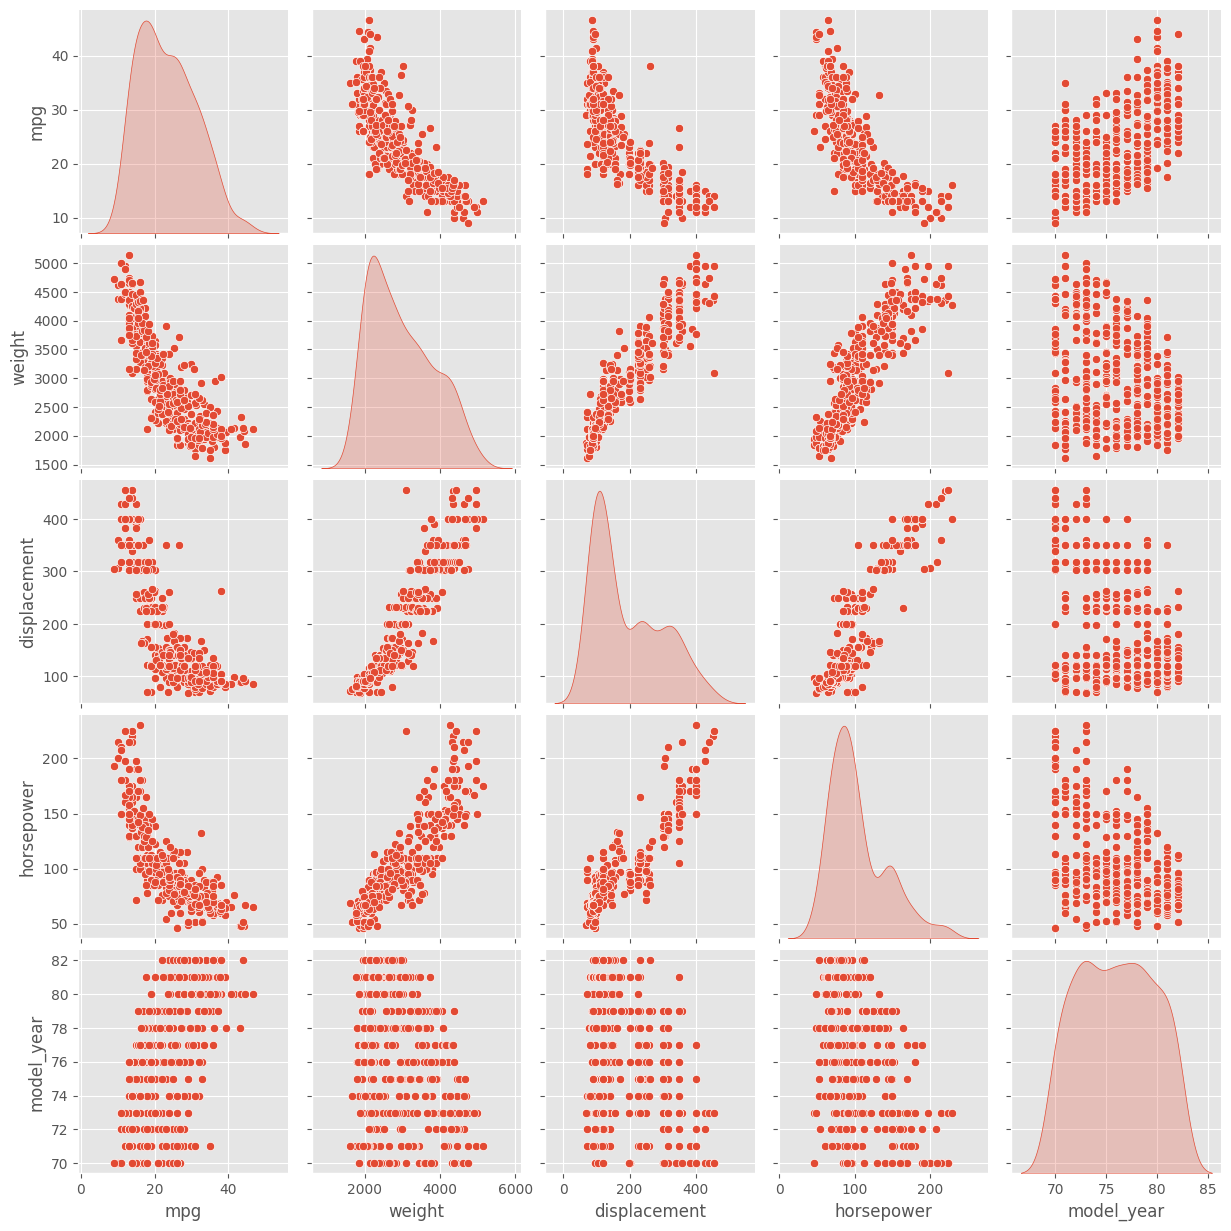

In [28]:
sns.pairplot(
    auto1[["mpg", "weight", "displacement", "horsepower", "model_year"]],
    diag_kind="kde"
)
plt.show()


**5. Feature Selection and Train–Test Split**

5.1  – Choose features and split data

In [29]:
# =====================================================
# 5. FEATURE SELECTION AND TRAIN–TEST SPLIT
# =====================================================

# Option A: full numeric feature set (keep model_year and origin)
features_full = ["cylinders", "displacement", "horsepower",
                 "weight", "acceleration", "model_year", "origin"]


target = "mpg"

# For now use full feature set for modelling
X = auto[features_full]
y = auto[target]

# Train–test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((313, 7), (79, 7), (313,), (79,))

In [30]:
# Option B: reduced feature set (drop model_year and origin)

features_reduced = ["cylinders", "displacement", "horsepower",
                    "weight", "acceleration"]

**6. Baseline Linear Regression Model**

6.1 Code – Train and evaluate Linear Regression with CV

In [31]:
# =====================================================
# 6. BASELINE MODEL – LINEAR REGRESSION
# =====================================================

baseline_model = LinearRegression()

# 5-fold cross-validation on training set
cv_rmse = cross_val_score(
    baseline_model, X_train, y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
cv_r2 = cross_val_score(
    baseline_model, X_train, y_train,
    cv=5,
    scoring="r2"
)

print("Linear Regression – fold RMSE:", -cv_rmse)
print("Linear Regression – fold R²:  ", cv_r2)
print("Average RMSE:", -cv_rmse.mean())
print("Average R²:", cv_r2.mean())

# Fit on full training data and evaluate on test set
baseline_model.fit(X_train, y_train)
y_pred_test = baseline_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("\nTest MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)


Linear Regression – fold RMSE: [3.25282444 3.30266335 2.98698626 4.05154028 3.86781656]
Linear Regression – fold R²:   [0.81435259 0.81074947 0.82497008 0.77933169 0.74808478]
Average RMSE: 3.492366176140289
Average R²: 0.7954977225864415

Test MSE: 9.627592864881494
Test RMSE: 3.10283626137144
Test R²: 0.8374898155078438


Check residuals for the Linear Regression baseline.

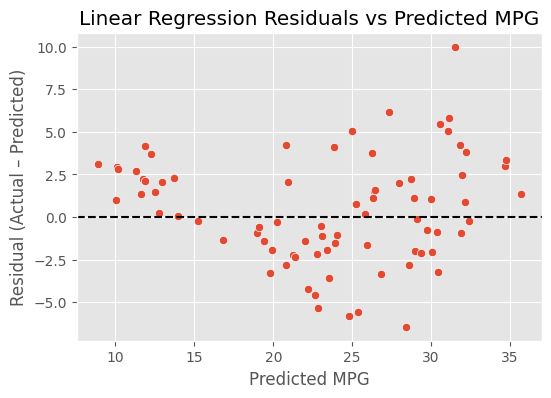

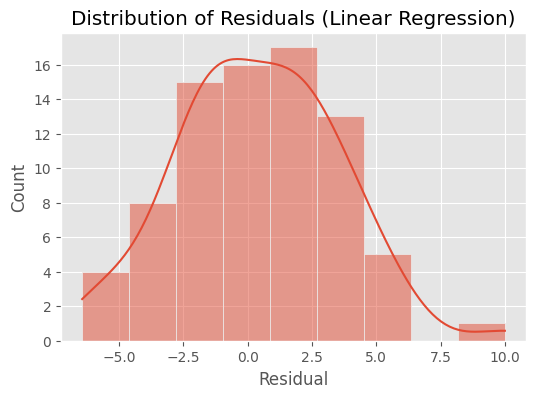

In [32]:
# Predicted vs actual on test set
y_pred_test = baseline_model.predict(X_test)

residuals = y_test - y_pred_test

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_test, y=residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted MPG")
plt.ylabel("Residual (Actual – Predicted)")
plt.title("Linear Regression Residuals vs Predicted MPG")
plt.show()

# Residual distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals (Linear Regression)")
plt.xlabel("Residual")
plt.show()


 the reduced feature set as a quick sensitivity check.

In [33]:
# Reduced feature set (no model_year, origin)
X_red = auto[features_reduced]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y,
    test_size=0.2,
    random_state=21
)

lin_red = LinearRegression()
cv_rmse_red = cross_val_score(
    lin_red, X_train_red, y_train_red,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
cv_r2_red = cross_val_score(
    lin_red, X_train_red, y_train_red,
    cv=5,
    scoring="r2"
)

print("Reduced Linear – Avg RMSE:", -cv_rmse_red.mean())
print("Reduced Linear – Avg R²:", cv_r2_red.mean())


Reduced Linear – Avg RMSE: 4.370397081006307
Reduced Linear – Avg R²: 0.6798170105549709


**WEEK 4**

7. Baseline Model Comparison with Cross‑Validation

7.1  – Define models and simple hyperparameter grids

In [34]:
# =====================================================
# 7. BASELINE AND REGULARISED MODELS + TREE MODELS
# =====================================================

from sklearn.model_selection import GridSearchCV

# 1) Linear Regression (already fitted as baseline_model)
linreg = LinearRegression()

# 2) Ridge Regression – small grid over alpha
ridge = Ridge()
ridge_params = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

# 3) Lasso Regression – small grid over alpha
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}

# 4) Decision Tree Regressor – depth and leaf size
dtr = DecisionTreeRegressor(random_state=21)
dtr_params = {
    "max_depth": [None, 3, 5, 7, 9],
    "min_samples_leaf": [1, 2, 4]
}

# 5) Random Forest Regressor – n_estimators and depth
rfr = RandomForestRegressor(random_state=21)
rfr_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


7.2  – Helper to run CV + optional GridSearch

In [35]:
def evaluate_model(name, model, param_grid=None):
    """
    If param_grid is provided, runs GridSearchCV (5-fold, RMSE).
    Otherwise, just does 5-fold CV for the base model.
    Returns best_estimator, avg_cv_rmse, avg_cv_r2.
    """
    if param_grid is not None:
        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=5,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        # Get CV scores for best model
        cv_rmse = -grid.best_score_
        # Recompute R² via cross_val_score for clarity
        cv_r2 = cross_val_score(
            best_model, X_train, y_train,
            cv=5,
            scoring="r2"
        ).mean()
    else:
        best_model = model
        cv_rmse_scores = cross_val_score(
            best_model, X_train, y_train,
            cv=5,
            scoring="neg_root_mean_squared_error"
        )
        cv_r2_scores = cross_val_score(
            best_model, X_train, y_train,
            cv=5,
            scoring="r2"
        )
        cv_rmse = -cv_rmse_scores.mean()
        cv_r2 = cv_r2_scores.mean()
        best_model.fit(X_train, y_train)

    print(f"{name} – Avg CV RMSE: {cv_rmse:.3f}, Avg CV R²: {cv_r2:.3f}")
    return best_model, cv_rmse, cv_r2


7.3  – Run all models

In [36]:
results = {}

# Linear Regression (no hyperparameters)
lin_best, lin_rmse, lin_r2 = evaluate_model("LinearRegression", linreg)
results["LinearRegression"] = (lin_rmse, lin_r2)

# Ridge
ridge_best, ridge_rmse, ridge_r2 = evaluate_model("Ridge", ridge, ridge_params)
results["Ridge"] = (ridge_rmse, ridge_r2)

# Lasso
lasso_best, lasso_rmse, lasso_r2 = evaluate_model("Lasso", lasso, lasso_params)
results["Lasso"] = (lasso_rmse, lasso_r2)

# Decision Tree
dtr_best, dtr_rmse, dtr_r2 = evaluate_model("DecisionTree", dtr, dtr_params)
results["DecisionTree"] = (dtr_rmse, dtr_r2)

# Random Forest
rfr_best, rfr_rmse, rfr_r2 = evaluate_model("RandomForest", rfr, rfr_params)
results["RandomForest"] = (rfr_rmse, rfr_r2)

results


LinearRegression – Avg CV RMSE: 3.492, Avg CV R²: 0.795
Ridge – Avg CV RMSE: 3.489, Avg CV R²: 0.796
Lasso – Avg CV RMSE: 3.490, Avg CV R²: 0.796
DecisionTree – Avg CV RMSE: 3.836, Avg CV R²: 0.753
RandomForest – Avg CV RMSE: 2.968, Avg CV R²: 0.850


{'LinearRegression': (np.float64(3.492366176140289),
  np.float64(0.7954977225864415)),
 'Ridge': (np.float64(3.4889776888551167), np.float64(0.7960328159993671)),
 'Lasso': (np.float64(3.4896206030644215), np.float64(0.7961261335582112)),
 'DecisionTree': (np.float64(3.8358751965830087),
  np.float64(0.7525262881561728)),
 'RandomForest': (np.float64(2.9680912234543615),
  np.float64(0.8500791026473195))}

small comparison plot:

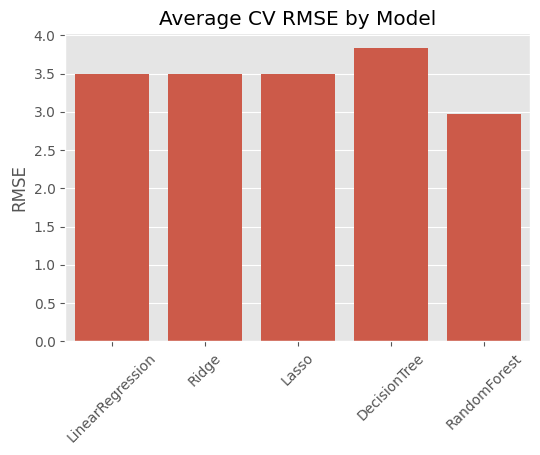

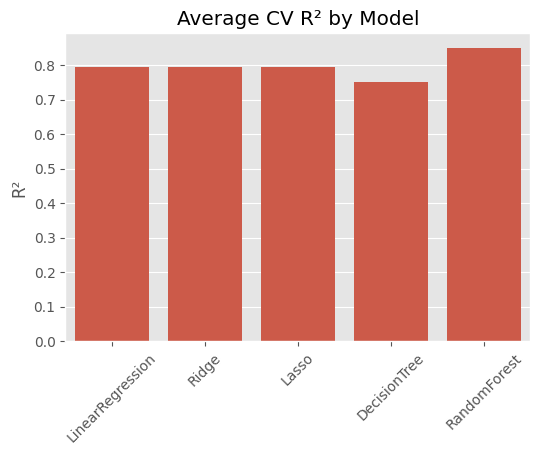

In [37]:
model_names = list(results.keys())
rmse_vals = [results[m][0] for m in model_names]
r2_vals = [results[m][1] for m in model_names]

plt.figure(figsize=(6,4))
sns.barplot(x=model_names, y=rmse_vals)
plt.title("Average CV RMSE by Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x=model_names, y=r2_vals)
plt.title("Average CV R² by Model")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()


8. Final Model: Random Forest Regressor

8.1  – Fit best Random Forest on full training set and evaluate on test set


In [38]:
# =====================================================
# 8. FINAL RANDOM FOREST MODEL
# =====================================================

# rfr_best comes from Section 7 GridSearchCV
final_rf = rfr_best

# Fit on full training data (if not already fitted)
final_rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = final_rf.predict(X_test)

# Metrics
rf_test_mse = mean_squared_error(y_test, y_pred_rf)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest – Test MSE:", rf_test_mse)
print("Random Forest – Test RMSE:", rf_test_rmse)
print("Random Forest – Test R²:", rf_test_r2)


Random Forest – Test MSE: 5.230879936708857
Random Forest – Test RMSE: 2.287111701843366
Random Forest – Test R²: 0.9117046934263627


8.2  – Predicted vs actual and feature importance

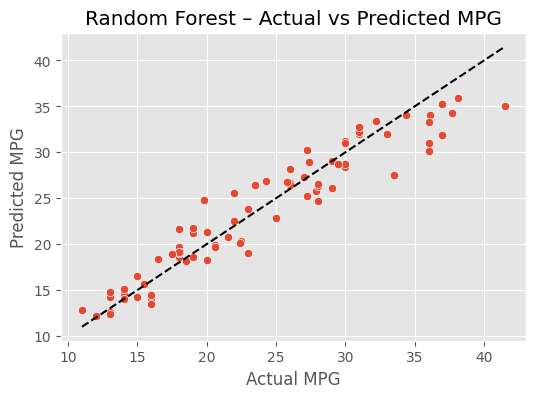

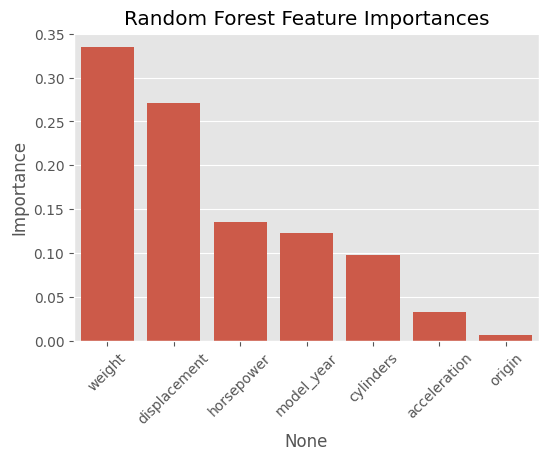

,0
weight,0.334460
displacement,0.270989
horsepower,0.135145
model_year,0.122980
cylinders,0.097350
acceleration,0.032262
origin,0.006813


In [39]:
# Predicted vs actual plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Random Forest – Actual vs Predicted MPG")
plt.show()

# Feature importance
importances = pd.Series(final_rf.feature_importances_, index=features_full)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.index, y=importances.values)
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

importances


 8.3 Additional Hyperparameter Tuning

In [40]:
rf = RandomForestRegressor(random_state=21)

rf_params_refined = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [1, 2],
    "max_features": ["auto", "sqrt", 0.5]
}

rf_grid = GridSearchCV(
    rf,
    param_grid=rf_params_refined,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
best_rf_rmse = -rf_grid.best_score_
best_rf_r2 = cross_val_score(
    best_rf, X_train, y_train,
    cv=5, scoring="r2"
).mean()


In [41]:
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV RMSE:", best_rf_rmse)
print("Best CV R²:", best_rf_r2)


Best Random Forest parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV RMSE: 2.954823282735063
Best CV R²: 0.8517231692327962


In [42]:
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

best_test_mse = mean_squared_error(y_test, y_pred_best)
best_test_rmse = np.sqrt(best_test_mse)
best_test_r2 = r2_score(y_test, y_pred_best)

print("Refined RF – Test RMSE:", best_test_rmse)
print("Refined RF – Test R²:", best_test_r2)


Refined RF – Test RMSE: 2.276529629274703
Refined RF – Test R²: 0.9125198576429948


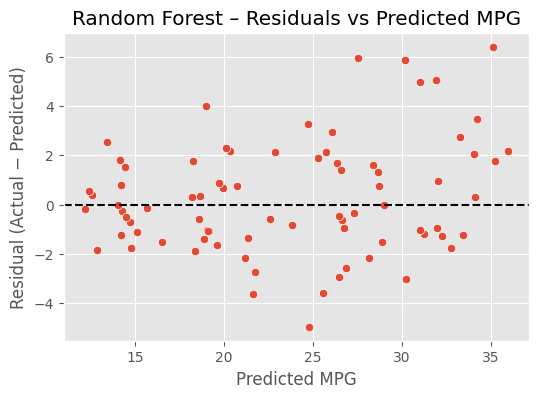

In [43]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted MPG")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Random Forest – Residuals vs Predicted MPG")
plt.show()
